In [349]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches
import seaborn as sns


df = pd.read_csv("shots_2023.csv")

In [350]:
df.info()
print("\n")
print(df.isnull().sum())
print("\n")
df['goal'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122472 entries, 0 to 122471
Columns: 124 entries, shotID to yCordAdjusted
dtypes: float64(38), int64(73), object(13)
memory usage: 115.9+ MB


shotID                       0
arenaAdjustedShotDistance    0
arenaAdjustedXCord           0
arenaAdjustedXCordABS        0
arenaAdjustedYCord           0
                            ..
xPlayStopped                 0
xRebound                     0
xShotWasOnGoal               0
yCord                        0
yCordAdjusted                0
Length: 124, dtype: int64




goal
0    113899
1      8573
Name: count, dtype: int64

In [351]:
goal_rate = df['goal'].sum() / len(df) * 100
print(f"{goal_rate:.2f}% of our shots result in goals")

7.00% of our shots result in goals


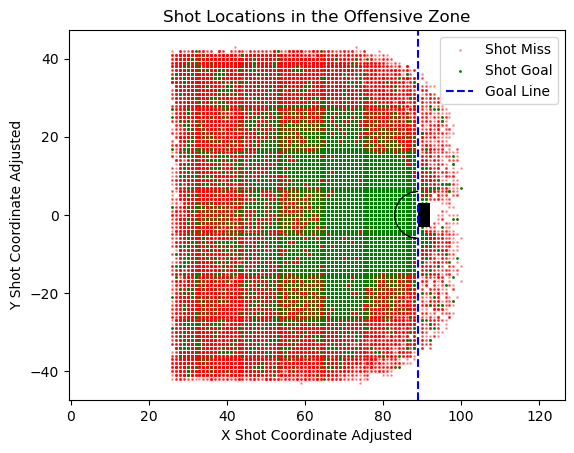

In [352]:
df_shots_in_attacking_zone = df[(df['xCordAdjusted'] > 25)]
shots_in_attacking_zone_x = df_shots_in_attacking_zone['xCordAdjusted']
shots_in_attacking_zone_y = df_shots_in_attacking_zone['yCordAdjusted']

goals_in_attacking_zone = df_shots_in_attacking_zone[(df_shots_in_attacking_zone['goal'] == 1)]
goals_in_attacking_zone_x = goals_in_attacking_zone['xCordAdjusted']
goals_in_attacking_zone_y = goals_in_attacking_zone['yCordAdjusted']

miss_in_attacking_zone = df_shots_in_attacking_zone[(df_shots_in_attacking_zone['goal'] == 0)]
miss_in_attacking_zone_x = miss_in_attacking_zone['xCordAdjusted']
miss_in_attacking_zone_y = miss_in_attacking_zone['yCordAdjusted']

fig, ax = plt.subplots()

ax.scatter(miss_in_attacking_zone_x, miss_in_attacking_zone_y, s=1, alpha=0.3, c='red', label='Shot Miss')
ax.scatter(goals_in_attacking_zone_x, goals_in_attacking_zone_y, s=1, alpha=1, c='green', label='Shot Goal')
ax.axis('equal')
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")

ax.axvline(x=89, c='blue', label='Goal Line', ls='dashed')
goal = matplotlib.patches.Rectangle((89, -3), 3, 6, fc='black')
ax.add_patch(goal)
crease = matplotlib.patches.Arc((89, 0), 12, 12, theta1=90 , theta2=270 , fill=False, edgecolor='black')
ax.add_patch(crease)

plt.title('Shot Locations in the Offensive Zone')
plt.legend(loc='upper right')
plt.show()

Here, I added a scatter plot displaying all shot attempts in the attacking zone of the hockey rink, with non-goal shots in red and goals in green. A clear pattern appears as expected, with goals clustering densely in the area directly in front of the goal, while non-goal shots spread across the entire offensive zone. This suggests that shot location captured through shot-distance and shot-angle can be of the strongest predictors in our xG model.

Chart Design Explanation:
1. Filter shots down to shots taken within the attacking zone, using adjusted coordinates to allow us to view all the data within only one half of the rink.
2. Grab the x and y coordinates of shots-taken and further filter down to x and y coordiantes of goals and misses in the attacking zone
3. Scatter our x and y shot coordinate data, color coding shots scored in green and shots missed in red
4. Add a rectangle to our plot using patches (ax necessary just for rectangle compatibility); add a vertical dashed line representing the goal line; add an arc representing the shot crease.

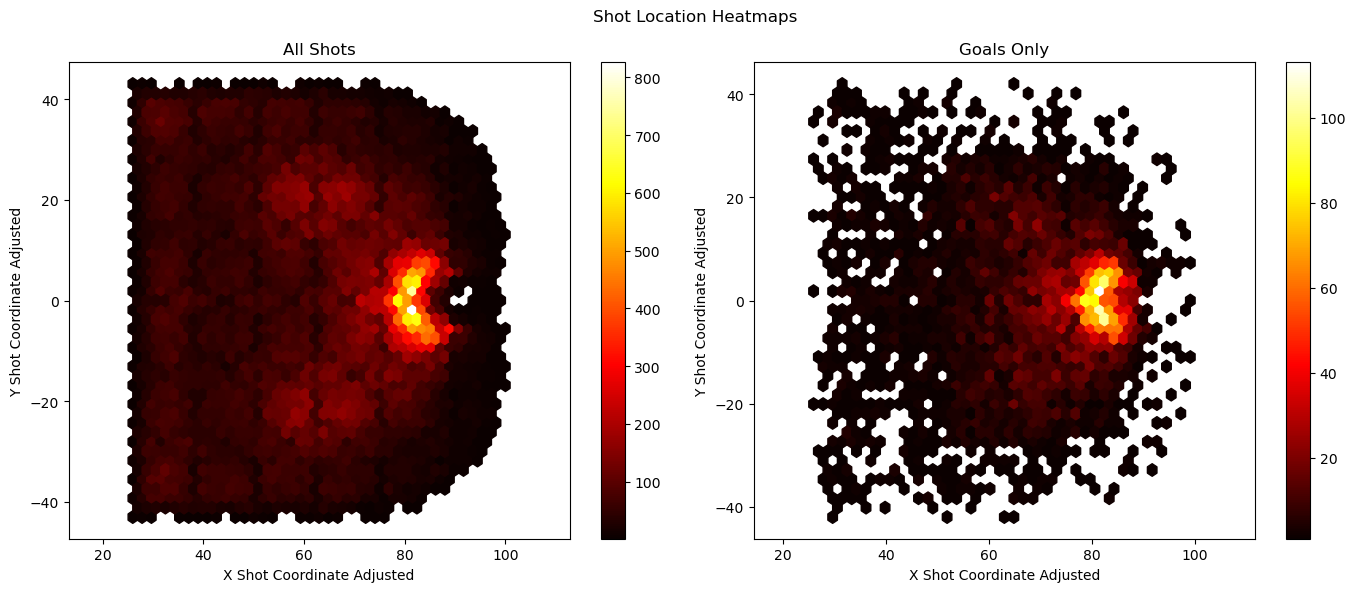

In [353]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hexbin(shots_in_attacking_zone_x, shots_in_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
plt.colorbar()
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")
plt.title("All Shots")
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.hexbin(goals_in_attacking_zone_x, goals_in_attacking_zone_y, gridsize=40, cmap='hot', mincnt=1)
plt.colorbar()
plt.xlabel("X Shot Coordinate Adjusted")
plt.ylabel("Y Shot Coordinate Adjusted")
plt.title("Goals Only")
plt.axis('equal')

plt.suptitle("Shot Location Heatmaps")
plt.tight_layout()
plt.show()

Here, I added 2 charts displaying heatmaps of our shot data: the left chart showing the clustering density of all shots taken and the right showing the clustering density of shots taken resulting in goals.
Most shots taken are shots directly in front of goal. On our left heatmap we see an interesting pattern within the shot density with an increase in clustering around the faceoff zones (x=60 and with a slight angle on goal at y=20 and y=-20.)
The right chart (goals only) is far more concentrated near the net than the left chart (all shots).

In [418]:
df['shootingTeamSkaters'] = np.where(df['isHomeTeam'] == 1, df['homeSkatersOnIce'], df['awaySkatersOnIce'])
df['defendingTeamSkaters'] = np.where(df['isHomeTeam'] == 0, df['homeSkatersOnIce'], df['awaySkatersOnIce'])
df['gameState'] = df['shootingTeamSkaters'].astype(str) + 'v' + df['defendingTeamSkaters'].astype(str)

In [419]:
df_game_state_samples = df[df['gameState'].isin(['5v5', '5v4', '4v5', '4v4'])]
columns = {
    'mean': 'Goal Rate',
    'count': 'Shots',
    'sum': 'Goals'
}
df_goal_rates = df_game_state_samples.groupby('gameState')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rates

,Goal Rate,Shots,Goals
gameState,,,
4v4,0.088951,1439,128
4v5,0.077935,2964,231
5v4,0.094526,17117,1618
5v5,0.059219,95425,5651


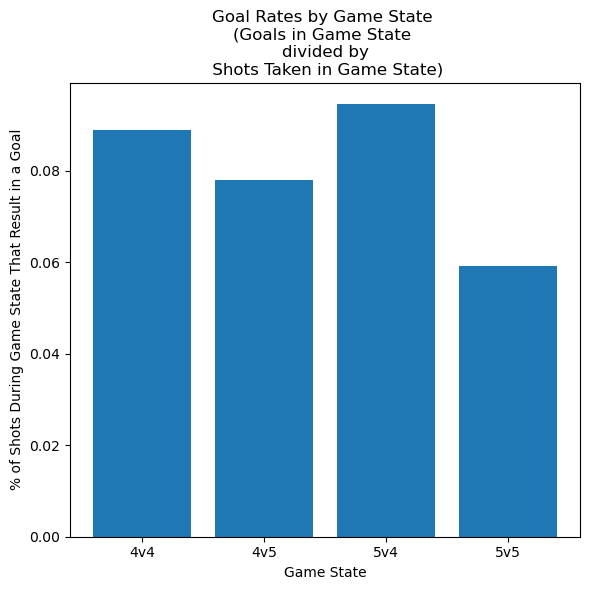

In [420]:
plt.figure(figsize=(6, 6))
plt.bar(df_goal_rates.index, df_goal_rates['Goal Rate'])
plt.xlabel("Game State")
plt.ylabel("% of Shots During Game State That Result in a Goal")
plt.title("Goal Rates by Game State \n(Goals in Game State \ndivided by\n Shots Taken in Game State)")
plt.tight_layout()
plt.show()

In [357]:
df_shot_rebound_goal_rates = df.groupby('shotRebound')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_rebound_goal_rates.index = ['No Rebound', 'Rebound']
df_shot_rebound_goal_rates

,Goal Rate,Shots,Goals
No Rebound,0.066070,113304,7486
Rebound,0.118565,9168,1087


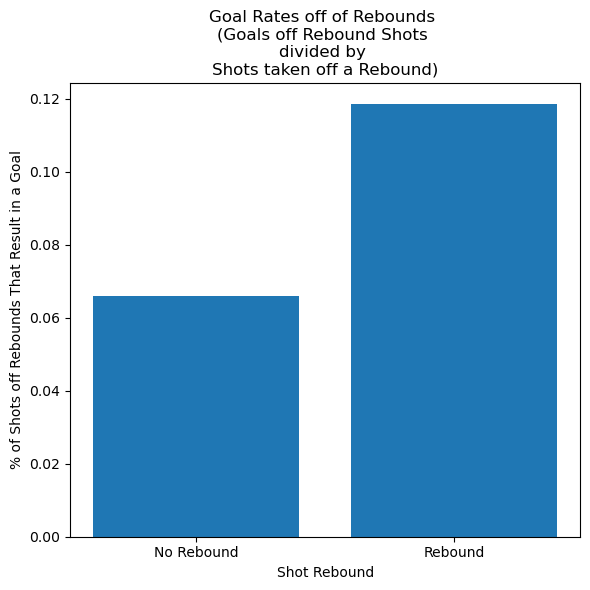

In [358]:
plt.figure(figsize=(6, 6))

plt.bar(df_shot_rebound_goal_rates.index, df_shot_rebound_goal_rates['Goal Rate'])
plt.xlabel("Shot Rebound")
plt.ylabel("% of Shots off Rebounds That Result in a Goal")
plt.title("Goal Rates off of Rebounds \n(Goals off Rebound Shots \ndivided by \nShots taken off a Rebound)")
plt.tight_layout()
plt.show()

In [359]:
df_shot_offWing_goal_rate = df.groupby('offWing')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_offWing_goal_rate.index = ['On Wing', 'Off Wing']
df_shot_offWing_goal_rate

,Goal Rate,Shots,Goals
On Wing,0.064729,72085,4666
Off Wing,0.077540,50387,3907


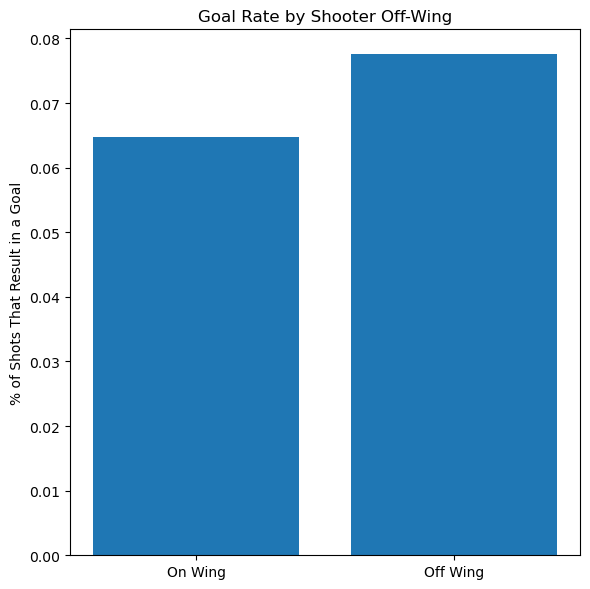

In [360]:
plt.figure(figsize=(6, 6))
plt.bar(df_shot_offWing_goal_rate.index, df_shot_offWing_goal_rate['Goal Rate'])
plt.xlabel("")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shooter Off-Wing")
plt.tight_layout()
plt.show()

In [361]:
max = df['shotDistance'].max()
min = df['shotDistance'].min()

bins = list(range(0, 110, 10))
labels = [f'{i}-{i+10}' for i in range(0, 100, 10)]
df['distanceBucket'] = pd.cut(df['shotDistance'], bins=bins, labels=labels)
df_shot_distance_goal_rate = df.groupby('distanceBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_distance_goal_rate

/var/folders/31/rg1c58bd67ggqzpv1vft110w0000gn/T/ipykernel_30468/4046548054.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_shot_distance_goal_rate = df.groupby('distanceBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)


,Goal Rate,Shots,Goals
distanceBucket,,,
0-10,0.143703,16214,2330
10-20,0.110296,21116,2329
20-30,0.089494,19208,1719
30-40,0.051163,21891,1120
40-50,0.030524,16872,515
50-60,0.021832,14245,311
60-70,0.016252,8922,145
70-80,0.029940,1837,55
80-90,0.022496,1378,31


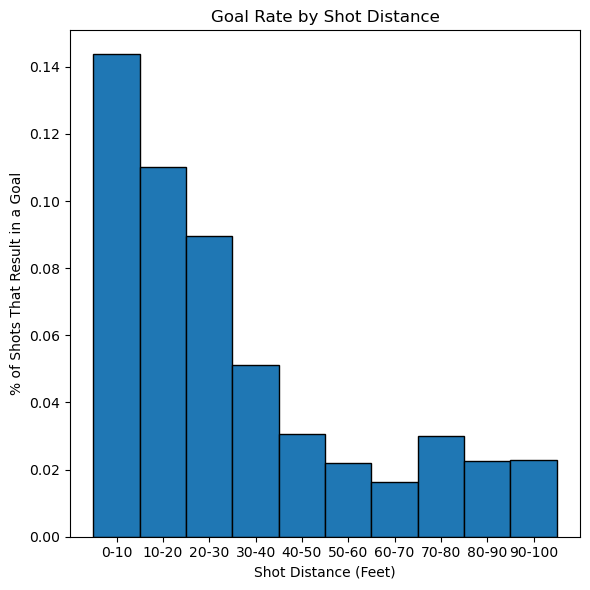

In [362]:
plt.figure(figsize=(6, 6))
plt.bar(df_shot_distance_goal_rate.index, df_shot_distance_goal_rate['Goal Rate'], width=1, edgecolor='black')
plt.xlabel("Shot Distance (Feet)")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shot Distance")
plt.tight_layout()
plt.show()

In [363]:
max_shotAngle = df['shotAngle'].max()
min_shotAngle = df['shotAngle'].min()
print(f"min: {min_shotAngle}, max: {max_shotAngle}")
bins = list(range(-95, 95, 10))
labels = []
for i in range (-90, 90, 10):
    if (i < 0):
        labels.append(f'({i})-({i+10})')
    else: 
        labels.append(f'{i}-{i+10}')
        
df['distanceBucket'] = pd.cut(df['shotAngle'], bins=bins, labels=labels)
df_shot_angle_goal_rate = df.groupby('distanceBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_angle_goal_rate

min: -88.451842301, max: 88.451842301


/var/folders/31/rg1c58bd67ggqzpv1vft110w0000gn/T/ipykernel_30468/2275638486.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_shot_angle_goal_rate = df.groupby('distanceBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)


,Goal Rate,Shots,Goals
distanceBucket,,,
(-90)-(-80),0.033771,533,18
(-80)-(-70),0.045683,2780,127
(-70)-(-60),0.061740,3207,198
(-60)-(-50),0.068698,4891,336
(-50)-(-40),0.072147,7554,545
(-40)-(-30),0.059399,8889,528
(-30)-(-20),0.062175,11532,717
(-20)-(-10),0.071799,9262,665
(-10)-(0),0.091818,8103,744


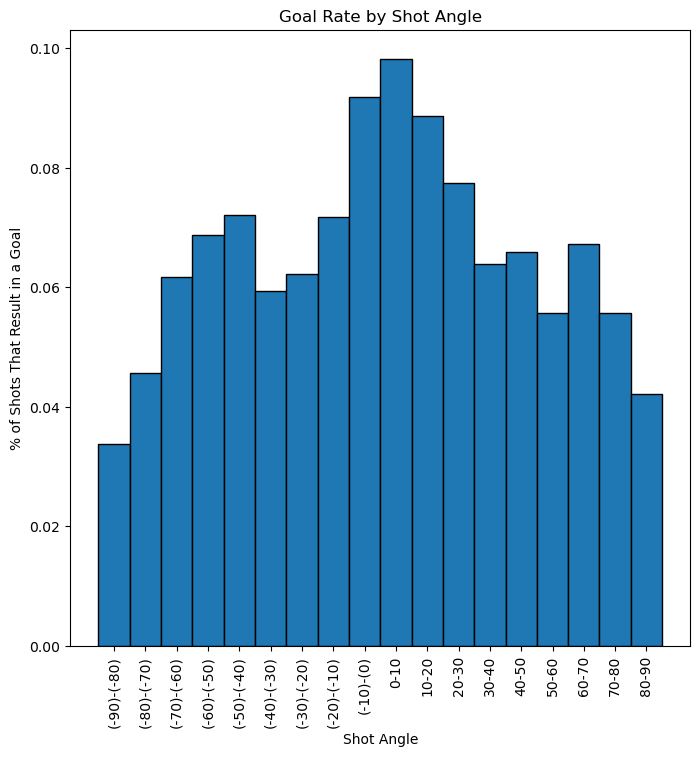

In [376]:
plt.figure(figsize=(8, 8))
plt.bar(df_shot_angle_goal_rate.index, df_shot_angle_goal_rate['Goal Rate'], width=1, edgecolor='black', )
plt.xticks(rotation=90)
plt.xlabel("Shot Angle")
plt.ylabel("% of Shots That Result in a Goal")
plt.title("Goal Rate by Shot Angle")
plt.show()

In [366]:
df_shots_with_goalie = df[(df['shotOnEmptyNet'] == 0.0)]

df_shot_type_goal_rate = df[(df['shotOnEmptyNet'] == 0.0)].groupby('shotType')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_shot_type_goal_rate.sort_values(by='Goal Rate', ascending=False)


,Goal Rate,Shots,Goals
shotType,,,
SNAP,0.091310,17216,1572
TIP,0.083326,10777,898
DEFL,0.082828,2475,205
BACK,0.079871,8664,692
WRIST,0.057611,66099,3808
WRAP,0.057576,990,57
SLAP,0.049503,14383,712


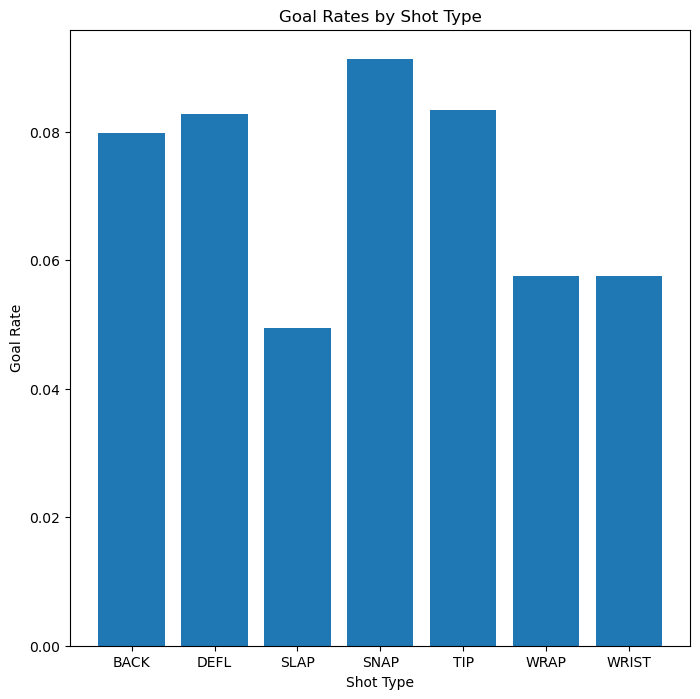

In [367]:
plt.figure(figsize=(8, 8))
plt.bar(df_shot_type_goal_rate.index, df_shot_type_goal_rate[('Goal Rate')])
plt.xlabel('Shot Type')
plt.ylabel('Goal Rate')
plt.title('Goal Rates by Shot Type')
plt.show()

In [368]:
reg_periods = [1, 2, 3]
df_shots_during_reg_time = df[(df['shotOnEmptyNet'] == 0) & (df['period'].isin(reg_periods))]

df_goal_rate_by_period = df_shots_during_reg_time.groupby('period')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rate_by_period

,Goal Rate,Shots,Goals
period,,,
1,0.063347,39386,2495
2,0.069746,41766,2913
3,0.063747,38841,2476


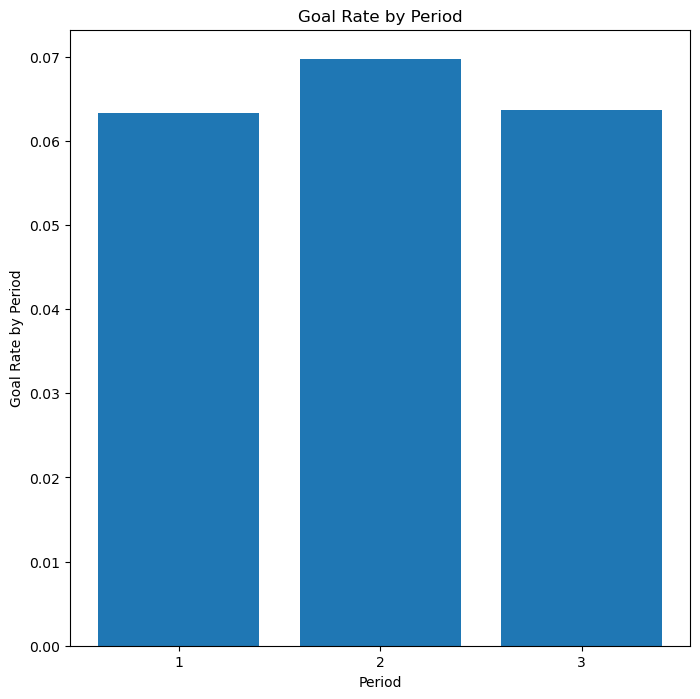

In [369]:
plt.figure(figsize=(8, 8))
plt.bar(df_goal_rate_by_period.index, df_goal_rate_by_period['Goal Rate'])
plt.xticks([1, 2, 3])
plt.xlabel('Period')
plt.ylabel('Goal Rate by Period')
plt.title('Goal Rate by Period')
plt.show()

In [395]:
df_event_categories = df[(df['lastEventCategory'] != 'CHL') & (df['lastEventCategory'] != 'STOP')]
df_event_categories['lastEventCategory'] = df_event_categories['lastEventCategory'].replace('DELPEN', 'DELAYED\nPENALTY')
df_goal_rate_last_event_category = df_event_categories.groupby('lastEventCategory')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_goal_rate_last_event_category

/var/folders/31/rg1c58bd67ggqzpv1vft110w0000gn/T/ipykernel_30468/4258994210.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_event_categories['lastEventCategory'] = df_event_categories['lastEventCategory'].replace('DELPEN', 'DELAYED\nPENALTY')


,Goal Rate,Shots,Goals
lastEventCategory,,,
BLOCK,0.071025,17149,1218
DELAYED\nPENALTY,0.152709,609,93
FAC,0.054242,30825,1672
GIVE,0.087507,9165,802
HIT,0.054849,19964,1095
MISS,0.072636,13671,993
SHOT,0.086655,23057,1998
TAKE,0.086729,8025,696


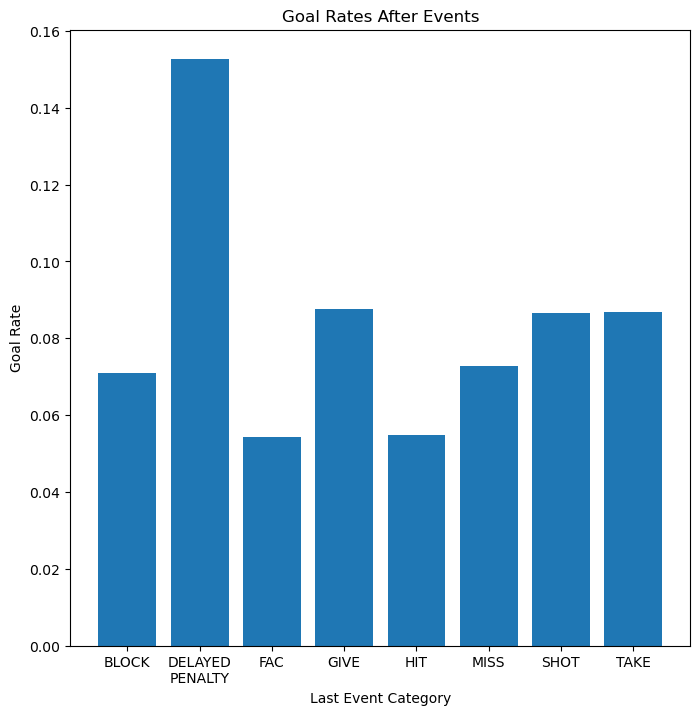

In [396]:
plt.figure(figsize=(8, 8))
plt.bar(df_goal_rate_last_event_category.index, df_goal_rate_last_event_category['Goal Rate'])
plt.xlabel('Last Event Category')
plt.ylabel('Goal Rate')
plt.title('Goal Rates After Events')
plt.show()

In [372]:
max_distance = df['distanceFromLastEvent'].max()
min_distance = df['distanceFromLastEvent'].min()
print(f"min: {min_distance}, max: {max_distance}")
bins = list(range(0, 210, 10))
labels = []
for i in range (0, 200, 10):
    if (i < 0):
        labels.append(f'({i})-({i+10})')
    else: 
        labels.append(f'{i}-{i+10}')
        
df['distanceFromLastEventBucket'] = pd.cut(df['distanceFromLastEvent'], bins=bins, labels=labels)
df_distance_from_last_event_goal_rate = df.groupby('distanceFromLastEventBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)
df_distance_from_last_event_goal_rate

min: 0.0, max: 198.406149098


/var/folders/31/rg1c58bd67ggqzpv1vft110w0000gn/T/ipykernel_30468/1205871053.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_distance_from_last_event_goal_rate = df.groupby('distanceFromLastEventBucket')['goal'].agg(['mean', 'count', 'sum']).rename(columns=columns)


,Goal Rate,Shots,Goals
distanceFromLastEventBucket,,,
0-10,0.103012,8533,879
10-20,0.087909,13514,1188
20-30,0.083980,15587,1309
30-40,0.069634,15639,1089
40-50,0.057121,13235,756
50-60,0.052328,10071,527
60-70,0.043849,7731,339
70-80,0.045366,5158,234
80-90,0.054228,3891,211


Text(0.5, 1.0, 'Goal Rate vs Distance From Last Event')

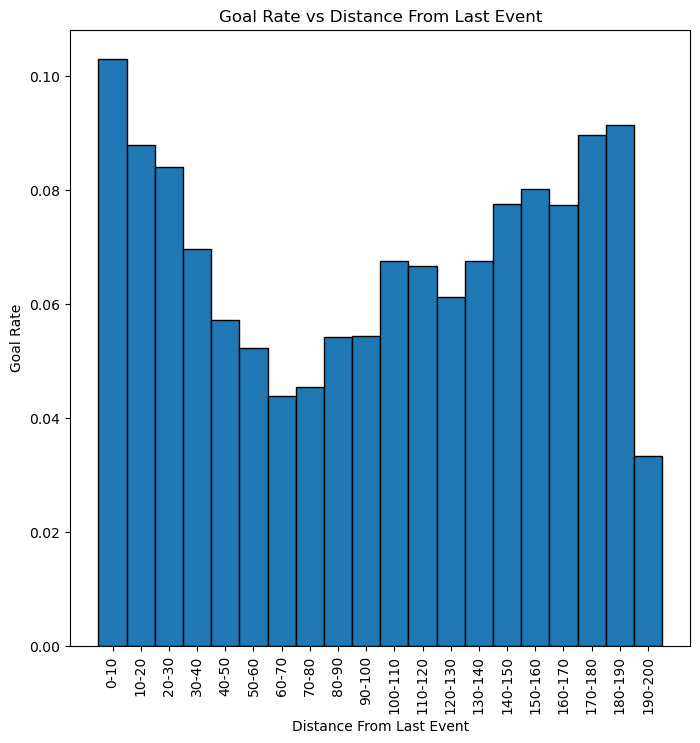

In [377]:
plt.figure(figsize=(8,8))
plt.bar(df_distance_from_last_event_goal_rate.index, df_distance_from_last_event_goal_rate['Goal Rate'], width=1, edgecolor='black', )
plt.xticks(rotation=90)
plt.xlabel('Distance From Last Event')
plt.ylabel('Goal Rate')
plt.title('Goal Rate vs Distance From Last Event')

In [402]:
df_features = df[['shotDistance', 'shotAngleAdjusted', 'shotRebound', 'offWing', 'shootingTeamSkaters', 'defendingTeamSkaters', 'period', 'distanceFromLastEvent', 'goal']]
corr_matrix = df_features.corr()
corr_matrix

,shotDistance,shotAngleAdjusted,shotRebound,offWing,shootingTeamSkaters,defendingTeamSkaters,period,distanceFromLastEvent,goal
shotDistance,1.000000,-0.246607,-0.267164,-0.156805,0.030852,0.125709,-0.007116,0.072599,-0.160848
shotAngleAdjusted,-0.246607,1.000000,0.081712,0.052458,0.005350,0.045619,0.002482,0.069494,-0.046417
shotRebound,-0.267164,0.081712,1.000000,0.025166,0.030592,-0.010097,-0.006405,-0.213115,0.054144
offWing,-0.156805,0.052458,0.025166,1.000000,-0.005693,-0.093067,0.014564,-0.050087,0.024707
shootingTeamSkaters,0.030852,0.005350,0.030592,-0.005693,1.000000,0.323309,-0.085801,-0.105925,-0.024168
defendingTeamSkaters,0.125709,0.045619,-0.010097,-0.093067,0.323309,1.000000,-0.091587,0.173860,-0.022659
period,-0.007116,0.002482,-0.006405,0.014564,-0.085801,-0.091587,1.000000,-0.003054,0.023986
distanceFromLastEvent,0.072599,0.069494,-0.213115,-0.050087,-0.105925,0.173860,-0.003054,1.000000,-0.020691
goal,-0.160848,-0.046417,0.054144,0.024707,-0.024168,-0.022659,0.023986,-0.020691,1.000000


Text(0.5, 1.0, 'Correlation Heatmap of Features')

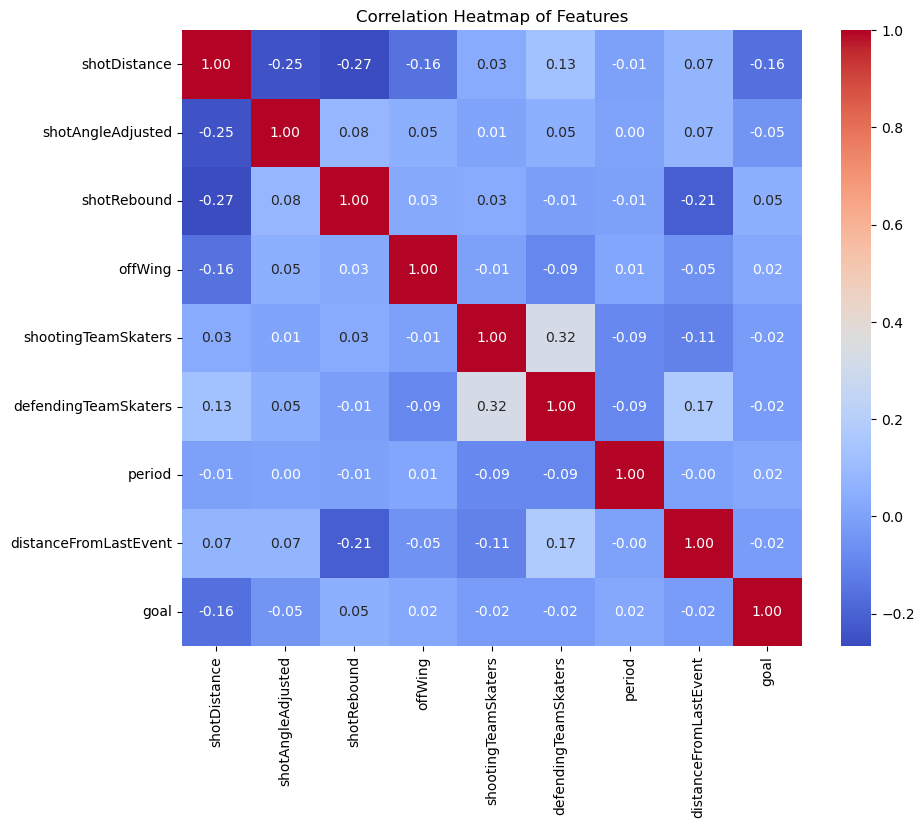

In [404]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Features")

Text(0.5, 1.0, 'Correlation Heatmap of Categorical Features')

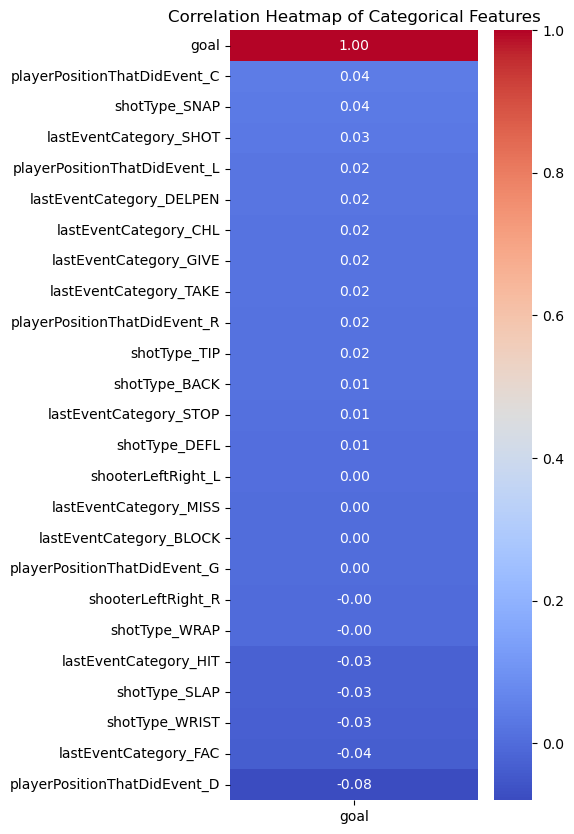

In [417]:
df_categorical_features = df[['shotType', 'lastEventCategory', 'shooterLeftRight', 'playerPositionThatDidEvent', 'goal']]
df_categorical_features = pd.get_dummies(df_categorical_features, drop_first=False)
corr_matrix = df_categorical_features.corr()[['goal']].sort_values(by='goal', ascending=False)
plt.figure(figsize=(4, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Categorical Features")